#**Comparing the Economic Impact of COVID-19: Australia and the Global Economy**

This project seeks to compare the economic consequences of the COVID-19 pandemic at both the global and national levels, with a specific focus on Australia. The analysis will utilise two core economic indicators: Gross Domestic Product (GDP), which reflects economic activity, and the Human Development Index (HDI), which captures broader aspects of human well-being.

##Table of Contents

[1. Introduction](#1-introduction)  
[2. Data Collection and Cleaning](#2-data-collection-and-cleaning)  
[3. Analysis and Visualisation](#3-analysis-and-visualisation)  
[4. Discussion](#4-discussion)  
[5. Conclusion](#5-conclusion)  
[6. Future Analysis](#6-future-analysis)  
[7. References](#7-references)  

## 1. Introduction

The COVID-19 pandemic, officially declared a global pandemic by the World Health Organization on 11 March 2020, has had far-reaching impacts across the globe, not only as a health crisis but also as a significant economic shock. According to the International Monetary Fund, the global economy experienced a decline of 3.1% in 2020, making it one of the sharpest downturns since the Great Depression. While all economies felt the disruption, the degree and nature of the government responses varied significantly, due to a range of factors such as politics, social behaviour and economic capacity.

The COVID-19 pandemic is of particular interest due to its global scale and the way it affected different nations, although often dramatically different. Australia presents an extreme case as it experienced one of the most stringent lockdowns as compared to other countries especially with regards to Melbourne where “Melbourne, Victoria’s capital city, has had more lockdowns due to the COVID-19 pandemic than any other city in the world” (CSIRO,2020). Australia adopted a ‘zero COVID’ approach within the early stages of the pandemic which included both strong state and international border closures. 

Personally, I found this topic compelling as I directly experienced the various stages of Australia’s COVID-19 response, from strict lockdowns to international border closures, and witnessed the economic ripple effects firsthand. When the pandemic began intensifying during the early 2020s was when I was undertaking one of the most important tests of my life in the Higher School Certificate (HSC). The pandemic not only affected this crucial academic milestone but also transformed my university experience, with a global shift to online learning from the traditional, in-person environment I had been accustomed to. At the same time, my household had just started a new restaurant shortly before the implementation of the Zero COVID policies and we faced significant financial hardship as well as the uncertainty and instability brought on by an ever changing landscape of prolonged lockdowns and restrictions.

This project focuses on comparing the consequences of the pandemic and its responses at both the global and national levels, with a particular emphasis on Australia. Within this project, there are two key indicators used: Gross Domestic Product Growth, which measures standardised economic output and the Human Development Index (HDI), which measures the broader human well-being. While GDP growth can capture the economic impacts that Covid had, HDI enables us to capture more aspects of life such as education, health and standard of living.

This project seeks to answer the following questions by using publicly available datasets on GDP and HDI across several years:

1. Rank the 20 countries with the highest mean Stringency Index  during 2020-2021. Where does Australia place?
2. Rank the 20 countries with the lowest mean Stringency Index during 2020-2021?
3. How did Australia’s economy perform during and after the pandemic compare to other countries with higher and lower Stringency Index?
4. How was Australia's HDI affected during COVID, as compared to the world?
5. Did Australia experience a slower or faster recovery in terms of Human Development Index (HDI) compared to similar countries?
6. Are a country's pre COVID HDI proportional to its economic recovery?
7. To what extent did Australia's strict lockdown policies reduce COVID deaths per 100k against other countries with higher and lower Stringency Index?

In the next sections, we will discuss the datasets that are to be used for analysis, inspect and clean the data and ultimately perform some analysis to answer our questions.

## 2. Data Collection and Cleaning

To start we must import all the required modules that we require for our coding

In [1]:
# Import required modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

**2.1 OxCGRT_timeseries_StringencyIndex_v1.csv**

The dataset is extracted from the GitHub repository of the Oxford COVID-19 Government Response Tracker (Hale et al., 2023).

The project as a whole systematically collected information on several different common policy responses governments took over 2020 to 2022 and recorded these policies on a scale to reflect the extent of government action, and quantified it. The dataset that we are using is a subset of the main dataset and its main columns are:
- CountryCode
- CountryName
  
These will help us index and merge with other datasets. The main feature of the dataset is the time series for the period covering 01/01/2020 to 28/02/2023 that reflects the strictness of government lockdown and containment policies using a index of 0-100. This index will help us quantitatively compare the degree of lockdown from different countries.

In [2]:
# Load data file OxCGRT_timeseries_StringencyIndex_v1.csv

stringency_index = pd.read_csv('OxCGRT_timeseries_StringencyIndex_v1.csv')
stringency_index

,CountryCode,CountryName,RegionCode,RegionName,CityCode,CityName,Jurisdiction,01Jan2020,02Jan2020,03Jan2020,...,19Feb2023,20Feb2023,21Feb2023,22Feb2023,23Feb2023,24Feb2023,25Feb2023,26Feb2023,27Feb2023,28Feb2023
0,ABW,Aruba,NaN,NaN,NaN,NaN,NAT_TOTAL,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,NaN,NaN,NaN,NaN,NAT_TOTAL,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AGO,Angola,NaN,NaN,NaN,NaN,NAT_TOTAL,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ALB,Albania,NaN,NaN,NaN,NaN,NAT_TOTAL,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AND,Andorra,NaN,NaN,NaN,NaN,NAT_TOTAL,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,VUT,Vanuatu,NaN,NaN,NaN,NaN,NAT_TOTAL,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
391,YEM,Yemen,NaN,NaN,NaN,NaN,NAT_TOTAL,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
392,ZAF,South Africa,NaN,NaN,NaN,NaN,NAT_TOTAL,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
393,ZMB,Zambia,NaN,NaN,NaN,NaN,NAT_TOTAL,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Check which columns have NaN
nan = stringency_index.isna().any()
columns_nan = nan[nan]
columns_nan

RegionCode    True
RegionName    True
CityCode      True
CityName      True
01Jan2023     True
              ... 
24Feb2023     True
25Feb2023     True
26Feb2023     True
27Feb2023     True
28Feb2023     True
Length: 63, dtype: bool

Since we are only interested in comparing countries and not their regions, we can drop from RegionCode to Jurisdiction as these are not our focus. Thus we will use groupby and average by country in order to see nation trends. Furthermore, all columns that are NaN within the time series should likewise be dropped as these means that there was no data recorded for that instance for some countries and thus comparing may be impractical. Futhermore, coincidentally the results give us the time series with columns containing NaN at the start 2023 which was when restrictions have mostly been discontinued worldwide hence unnecessary for our analysis

In [4]:
# Remove columns that contain any NaN
stringency_index = stringency_index.dropna(axis=1, how='any')
stringency_index.head()

,CountryCode,CountryName,Jurisdiction,01Jan2020,02Jan2020,03Jan2020,04Jan2020,05Jan2020,06Jan2020,07Jan2020,...,22Dec2022,23Dec2022,24Dec2022,25Dec2022,26Dec2022,27Dec2022,28Dec2022,29Dec2022,30Dec2022,31Dec2022
0,ABW,Aruba,NAT_TOTAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,25.93,25.93,25.93,25.93,25.93,25.93,25.93,25.93,25.93,25.93
1,AFG,Afghanistan,NAT_TOTAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,AGO,Angola,NAT_TOTAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,17.02,17.02,17.02,17.02,17.02,17.02,17.02,17.02,17.02,17.02
3,ALB,Albania,NAT_TOTAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,11.11,11.11,11.11,11.11,11.11,11.11,11.11,11.11,11.11,11.11
4,AND,Andorra,NAT_TOTAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,11.11,11.11,11.11,11.11,11.11,11.11,11.11,11.11,11.11,11.11


In [5]:
# Drop the last unused column

In [6]:
stringency_index = stringency_index.drop('Jurisdiction', axis=1)
stringency_index.head()

,CountryCode,CountryName,01Jan2020,02Jan2020,03Jan2020,04Jan2020,05Jan2020,06Jan2020,07Jan2020,08Jan2020,...,22Dec2022,23Dec2022,24Dec2022,25Dec2022,26Dec2022,27Dec2022,28Dec2022,29Dec2022,30Dec2022,31Dec2022
0,ABW,Aruba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,25.93,25.93,25.93,25.93,25.93,25.93,25.93,25.93,25.93,25.93
1,AFG,Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,AGO,Angola,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,17.02,17.02,17.02,17.02,17.02,17.02,17.02,17.02,17.02,17.02
3,ALB,Albania,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,11.11,11.11,11.11,11.11,11.11,11.11,11.11,11.11,11.11,11.11
4,AND,Andorra,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,11.11,11.11,11.11,11.11,11.11,11.11,11.11,11.11,11.11,11.11


Now we need to average all the measures of the year to get a average index for a given year from 2020-2022

In [7]:
# Get only the columns that are the time series
time_series = stringency_index.columns[2:]

# Convert column names to datetime
stringency_ts = pd.to_datetime(time_series, format='%d%b%Y')

# Make a copy to work with
ts = stringency_index[time_series].copy()
ts.columns = stringency_ts

# Create new columns on orginal data set using copy
stringency_index['StringencyIndex_2020'] = ts[ts.columns[ts.columns.year == 2020]].mean(axis=1)
stringency_index['StringencyIndex_2021'] = ts[ts.columns[ts.columns.year == 2021]].mean(axis=1)
stringency_index['StringencyIndex_2022'] = ts[ts.columns[ts.columns.year == 2022]].mean(axis=1)

In [8]:
# Make new stringency_index using only the columns we need then groupby country
stringency_index = stringency_index[['CountryCode','CountryName', 'StringencyIndex_2020', 'StringencyIndex_2021', 'StringencyIndex_2022']]
print(stringency_index['CountryName'].nunique())
stringency_index = stringency_index.groupby('CountryName').mean(numeric_only=True).reset_index()
stringency_index

185


,CountryName,StringencyIndex_2020,StringencyIndex_2021,StringencyIndex_2022
0,Afghanistan,41.487268,29.242219,11.415644
1,Albania,55.196120,48.590904,21.522548
2,Algeria,60.224290,59.291781,25.554630
3,Andorra,38.216995,49.393644,12.836712
4,Angola,58.326913,58.863068,37.656849
...,...,...,...,...
180,Venezuela,68.010601,77.729041,19.829589
181,Vietnam,57.667158,69.148493,37.224575
182,Yemen,31.260874,31.496411,13.559068
183,Zambia,38.316694,41.567342,15.472685


After getting average for the stringency index and grouping by country to get national average our dataset for OxCGRT_timeseries_StringencyIndex_v1 has been cleaned for what we need with CountryName being the connecting factor to our other datasets. We get 3 tidy columns of stringency index for the years: 2020, 2021 and 2022. We also get 185 rows indicating the data for 185 countries which is just shy of the oficially recognised 195 countries (worldometers, 2025) but this can be discuss later on as it should not impact our analysis.

**2.2 API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_2673.csv**

This GDP‑growth dataset is sourced from the World Bank World Development Indicators portal (World Development Indicators, 2025).

It captures the year on year growth on GDP for a country which enables us to fairly compare different countries of different status. It captures the years from 1960 up to 2024. The main columns are:
- Country Name
- Columns from 1960 to 2024 with GDP growth

Similar to our last dataset, this dataset is simplistic in nature with our main concerns being our Country Name for identification and the columns of years that we are interested in.

In [9]:
# Load data file API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_2673.csv
# Skip rows as first 4 were metadata
gdp = pd.read_csv('API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_2673.csv', skiprows=4)
gdp

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,1.719625,7.048533,2.397085,-2.232440,-26.211821,24.132627,8.517918,4.263719,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,0.468736,7.869709,5.622374,4.690458,5.159574,...,2.194761,2.684543,2.666632,2.194319,-2.864293,4.576393,3.553878,2.320138,NaN,NaN
2,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,2.260314,2.647003,1.189228,3.911603,-2.351101,-20.738839,-6.240172,2.710887,NaN,NaN
3,Africa Western and Central,AFW,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,1.873054,3.712777,7.111968,5.413943,4.120855,...,0.160782,2.289810,2.844755,3.232903,-1.003994,4.037630,3.789680,3.354733,NaN,NaN
4,Angola,AGO,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-2.580050,-0.147213,-1.316362,-0.702273,-5.638215,1.199211,3.044727,1.001289,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,5.571775,4.825656,3.406632,4.756801,-5.340275,10.745656,4.278499,4.067627,NaN,NaN
262,"Yemen, Rep.",YEM,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-9.375124,-5.071796,0.752448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,3.844734,6.177931,7.373709,7.939609,6.122798,...,0.664552,1.157947,1.556784,0.259936,-6.168918,4.955033,1.911480,0.698485,NaN,NaN
264,Zambia,ZMB,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,1.361382,-2.490839,3.272393,12.214048,16.647456,...,3.755100,3.525863,4.034494,1.441306,-2.785055,6.234922,5.211224,5.367943,NaN,NaN


In [10]:
# Check which columns have NaN
nan_gdp = gdp.isna().any()
columns_nan_gdp = nan_gdp[nan_gdp]
columns_nan_gdp

1960           True
1961           True
1962           True
1963           True
1964           True
               ... 
2021           True
2022           True
2023           True
2024           True
Unnamed: 69    True
Length: 66, dtype: bool

Although there is NaN for all 1960-2024, it may be caused as either some countries did not exist during such periods or did not engage in reporting their GDP. Thus we will first select our needed columns then check again if any still persist. Years of interest is only for 2020-2023 as this allows us to analysis the effects of the lockdowns and after when it is no longer deemed necessary.

In [11]:
# Select only the coumns we need
selected_gdp = gdp[['Country Name'] + list(gdp.loc[:, '2020':'2023'].columns)]
selected_gdp.head()

,Country Name,2020,2021,2022,2023
0,Aruba,-26.211821,24.132627,8.517918,4.263719
1,Africa Eastern and Southern,-2.864293,4.576393,3.553878,2.320138
2,Afghanistan,-2.351101,-20.738839,-6.240172,2.710887
3,Africa Western and Central,-1.003994,4.037630,3.789680,3.354733
4,Angola,-5.638215,1.199211,3.044727,1.001289


In [12]:
# rename columns for consistency and differentiate when merged
selected_gdp.rename(columns={
    'Country Name': 'CountryName',
    '2020': 'GDPGrowth_2020',
    '2021': 'GDPGrowth_2021',
    '2022': 'GDPGrowth_2022',
    '2023': 'GDPGrowth_2023'
}, inplace = True)
selected_gdp.head()

C:\Users\kelvi\AppData\Local\Temp\ipykernel_12500\858135062.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_gdp.rename(columns={


,CountryName,GDPGrowth_2020,GDPGrowth_2021,GDPGrowth_2022,GDPGrowth_2023
0,Aruba,-26.211821,24.132627,8.517918,4.263719
1,Africa Eastern and Southern,-2.864293,4.576393,3.553878,2.320138
2,Afghanistan,-2.351101,-20.738839,-6.240172,2.710887
3,Africa Western and Central,-1.003994,4.037630,3.789680,3.354733
4,Angola,-5.638215,1.199211,3.044727,1.001289


Now, we would like to drop the countries that have NaN values within the GDP rows as we cannot use them

In [13]:
selected_gdp.dropna(inplace=True)
selected_gdp.reset_index(drop=True, inplace=True)
selected_gdp

C:\Users\kelvi\AppData\Local\Temp\ipykernel_12500\3048472340.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_gdp.dropna(inplace=True)


,CountryName,GDPGrowth_2020,GDPGrowth_2021,GDPGrowth_2022,GDPGrowth_2023
0,Aruba,-26.211821,24.132627,8.517918,4.263719
1,Africa Eastern and Southern,-2.864293,4.576393,3.553878,2.320138
2,Afghanistan,-2.351101,-20.738839,-6.240172,2.710887
3,Africa Western and Central,-1.003994,4.037630,3.789680,3.354733
4,Angola,-5.638215,1.199211,3.044727,1.001289
...,...,...,...,...,...
238,Samoa,-3.108444,-7.078831,-5.306291,8.584091
239,Kosovo,-5.340275,10.745656,4.278499,4.067627
240,South Africa,-6.168918,4.955033,1.911480,0.698485
241,Zambia,-2.785055,6.234922,5.211224,5.367943


Our dataset for GDP hsa now been cleaned and is ready to merge. This dataset contains 243 rows with values for 2020-2023 for GDP growth for each country. Interestingly it has a lot more number of countries as our previous dataset as well as the officially recognised amount of 195. This may be the case as there as some countries such as Aruba that although is a country, it still nevertheless belongs to another entity.

In [14]:
# Merge datasets

GDP_stringency = pd.merge(stringency_index, selected_gdp, on='CountryName', how='inner')
GDP_stringency

,CountryName,StringencyIndex_2020,StringencyIndex_2021,StringencyIndex_2022,GDPGrowth_2020,GDPGrowth_2021,GDPGrowth_2022,GDPGrowth_2023
0,Afghanistan,41.487268,29.242219,11.415644,-2.351101,-20.738839,-6.240172,2.710887
1,Albania,55.196120,48.590904,21.522548,-3.313716,8.969553,4.826688,3.936625
2,Algeria,60.224290,59.291781,25.554630,-5.000000,3.800000,3.600000,4.100000
3,Andorra,38.216995,49.393644,12.836712,-11.183940,8.286779,9.564612,2.583555
4,Angola,58.326913,58.863068,37.656849,-5.638215,1.199211,3.044727,1.001289
...,...,...,...,...,...,...,...,...
148,Uruguay,40.196803,56.928438,15.255945,-7.380142,5.561893,4.707258,0.367475
149,Uzbekistan,50.816148,44.612411,20.527315,1.563343,8.034683,6.001342,6.291416
150,Vanuatu,34.548333,21.283945,31.889644,-4.992491,-1.552295,1.916057,2.212942
151,Zambia,38.316694,41.567342,15.472685,-2.785055,6.234922,5.211224,5.367943


**2.3 hdr-data.xlsx**

The dataset is extracted from the data centre of United Nations Development Programme (UNDP,2023)

The UNDP is the United Nation's global development network. AS such it has developed the HDI system which measures changes in a broader well-being for a particular country. The HDI index ranges from 0-1 with 1 being perfect. The main columns of this dataset is:
- country
- year
- value

The format of this dataset is a bit different as it has its year values as a column with the value following it. Thus we should change it accordingly to match our needs.


In [15]:
# Load data file hdr-data.xlsx.csv

hdi = pd.read_excel("hdr-data.xlsx")
hdi.head()

,countryIsoCode,country,indexCode,index,dimension,indicatorCode,indicator,year,value,note
0,AFG,Afghanistan,HDI,Human Development Index,NaN,hdi,Human Development Index (value),1990,0.285,NaN
1,AFG,Afghanistan,HDI,Human Development Index,NaN,hdi,Human Development Index (value),1991,0.291,NaN
2,AFG,Afghanistan,HDI,Human Development Index,NaN,hdi,Human Development Index (value),1992,0.301,NaN
3,AFG,Afghanistan,HDI,Human Development Index,NaN,hdi,Human Development Index (value),1993,0.311,NaN
4,AFG,Afghanistan,HDI,Human Development Index,NaN,hdi,Human Development Index (value),1994,0.305,NaN


In [16]:
# Begin by selecting our needed columns
hdi = hdi[['country', 'year', 'value']]
hdi.head()

,country,year,value
0,Afghanistan,1990,0.285
1,Afghanistan,1991,0.291
2,Afghanistan,1992,0.301
3,Afghanistan,1993,0.311
4,Afghanistan,1994,0.305


In [17]:
# Need to use pivot tables to get countries as rows and year as columns
adjusted_hdi = (
    hdi.pivot(index='country',   
             columns='year',
             values='value').reset_index()
)

In [18]:
# Select required columns and rename
new_hdi = adjusted_hdi[['country'] + list(adjusted_hdi.loc[:, 2019:2023].columns)]
new_hdi.rename(columns={
    'country': 'CountryName',
    2019: 'HDI_2019',
    2020: 'HDI_2020',
    2021: 'HDI_2021',
    2022: 'HDI_2022',
    2023: 'HDI_2023'
}, inplace = True)
new_hdi.head()

C:\Users\kelvi\AppData\Local\Temp\ipykernel_12500\3182681307.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_hdi.rename(columns={


year,CountryName,HDI_2019,HDI_2020,HDI_2021,HDI_2022,HDI_2023
0,Afghanistan,0.507,0.501,0.486,0.495,0.496
1,Albania,0.805,0.794,0.794,0.806,0.810
2,Algeria,0.753,0.742,0.755,0.761,0.763
3,Andorra,0.876,0.851,0.871,0.893,0.913
4,Angola,0.611,0.610,0.609,0.615,0.616


In [19]:
# Check which columns have NaN
nan = new_hdi.isna().any()
columns_nan = nan[nan]
columns_nan

year
HDI_2019    True
HDI_2020    True
HDI_2021    True
HDI_2022    True
dtype: bool

In [20]:
# Drop na
new_hdi.dropna(inplace=True)

C:\Users\kelvi\AppData\Local\Temp\ipykernel_12500\4008593851.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_hdi.dropna(inplace=True)


In [21]:
# Merge datasets

GDP_stringency_hdi = pd.merge(GDP_stringency, new_hdi, on='CountryName', how='inner')
GDP_stringency_hdi

,CountryName,StringencyIndex_2020,StringencyIndex_2021,StringencyIndex_2022,GDPGrowth_2020,GDPGrowth_2021,GDPGrowth_2022,GDPGrowth_2023,HDI_2019,HDI_2020,HDI_2021,HDI_2022,HDI_2023
0,Afghanistan,41.487268,29.242219,11.415644,-2.351101,-20.738839,-6.240172,2.710887,0.507,0.501,0.486,0.495,0.496
1,Albania,55.196120,48.590904,21.522548,-3.313716,8.969553,4.826688,3.936625,0.805,0.794,0.794,0.806,0.810
2,Algeria,60.224290,59.291781,25.554630,-5.000000,3.800000,3.600000,4.100000,0.753,0.742,0.755,0.761,0.763
3,Andorra,38.216995,49.393644,12.836712,-11.183940,8.286779,9.564612,2.583555,0.876,0.851,0.871,0.893,0.913
4,Angola,58.326913,58.863068,37.656849,-5.638215,1.199211,3.044727,1.001289,0.611,0.610,0.609,0.615,0.616
...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,Uruguay,40.196803,56.928438,15.255945,-7.380142,5.561893,4.707258,0.367475,0.830,0.837,0.837,0.852,0.862
135,Uzbekistan,50.816148,44.612411,20.527315,1.563343,8.034683,6.001342,6.291416,0.730,0.723,0.727,0.737,0.740
136,Vanuatu,34.548333,21.283945,31.889644,-4.992491,-1.552295,1.916057,2.212942,0.622,0.617,0.615,0.621,0.621
137,Zambia,38.316694,41.567342,15.472685,-2.785055,6.234922,5.211224,5.367943,0.578,0.578,0.574,0.589,0.595


**2.4 WHO-COVID-19-global-data.csv & API_SP.POP.TOTL_DS2_en_csv_v2_2590.csv**

The dataset is obtained from the WHO COVID-19 dashboard (World Health Organization, 2025))

WHO has been monitoring and recording data from the begining of COVID. This data set is the aggregation of weekly COVID‑19 cases and deaths by date reported to WHO by countries. Our main columns of interest are:
- Date_reported
- Country
- New_deaths

Date_reported allows us to aggregate our New_deaths by year where New_deaths is the number of new deaths due to COVID. Once again we will use Country as a common factor to merge with our dataset

Furthermore, we will use another dataset API_SP.POP.TOTL_DS2_en_csv_v2_2590.csv to gain information about the population of a country so that we can calculate the number of Covid deaths per 100,000. Main columns are:
- Country Name
- Columns from 1960 to 2024 with population number

Country Name will help us index and merge with other datasets. While the columns for the period covering from  1960-2024 is just simply the population number

In [22]:
# Load data file WHO-COVID-19-global-data.csv
deaths = pd.read_csv('WHO-COVID-19-global-data.csv')
deaths

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-05,AF,Afghanistan,EMRO,NaN,0,NaN,0
1,2020-01-12,AF,Afghanistan,EMRO,NaN,0,NaN,0
2,2020-01-19,AF,Afghanistan,EMRO,NaN,0,NaN,0
3,2020-01-26,AF,Afghanistan,EMRO,NaN,0,NaN,0
4,2020-02-02,AF,Afghanistan,EMRO,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...
67675,2025-04-27,ZW,Zimbabwe,AFRO,0.0,266424,NaN,5740
67676,2025-05-04,ZW,Zimbabwe,AFRO,0.0,266424,NaN,5740
67677,2025-05-11,ZW,Zimbabwe,AFRO,NaN,266424,NaN,5740
67678,2025-05-18,ZW,Zimbabwe,AFRO,NaN,266424,NaN,5740


In [23]:
# Load data file API_SP.POP.TOTL_DS2_en_csv_v2_2590.csv
# Skip rows as first 4 were metadata
pop = pd.read_csv('API_SP.POP.TOTL_DS2_en_csv_v2_2590.csv', skiprows=4)
pop

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,NaN,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130072080.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,NaN,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,NaN,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,NaN,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,"Population, total",SP.POP.TOTL,984846.0,1011421.0,1036950.0,1062737.0,1090270.0,1120168.0,...,1777568.0,1791019.0,1797086.0,1788891.0,1790152.0,1786080.0,1768096.0,1756366.0,NaN,NaN
262,"Yemen, Rep.",YEM,"Population, total",SP.POP.TOTL,5532301.0,5655232.0,5782221.0,5911135.0,6048006.0,6195593.0,...,32109010.0,33090921.0,34085182.0,35111408.0,36134863.0,37140230.0,38222876.0,39390799.0,NaN,NaN
263,South Africa,ZAF,"Population, total",SP.POP.TOTL,16440172.0,16908035.0,17418522.0,17954564.0,18511361.0,19089380.0,...,57259551.0,57635162.0,58613001.0,59587885.0,60562381.0,61502603.0,62378410.0,63212384.0,NaN,NaN
264,Zambia,ZMB,"Population, total",SP.POP.TOTL,3153729.0,3254086.0,3358099.0,3465907.0,3577017.0,3692086.0,...,16914423.0,17441320.0,17973569.0,18513839.0,19059395.0,19603607.0,20152938.0,20723965.0,NaN,NaN


Since some values are NaN for New_deaths, it is equivalent to zero for our use case so we can effectively fill them as 0

In [24]:
# Select required columns and fillna
deaths = deaths[['Date_reported', 'Country', 'New_deaths']]
deaths.fillna(0).head()

,Date_reported,Country,New_deaths
0,2020-01-05,Afghanistan,0.0
1,2020-01-12,Afghanistan,0.0
2,2020-01-19,Afghanistan,0.0
3,2020-01-26,Afghanistan,0.0
4,2020-02-02,Afghanistan,0.0


In [25]:
# Groupby year and aggregate total death by year for each country
deaths['Date_reported'] = pd.to_datetime(deaths['Date_reported'])

# Create new column
deaths['Year'] = deaths['Date_reported'].dt.year

# Groupby Country and Year then aggregate deaths
deaths = (
    deaths.groupby(['Country', 'Year'], as_index=False)['New_deaths'].sum()
)
deaths

C:\Users\kelvi\AppData\Local\Temp\ipykernel_12500\2867230980.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deaths['Date_reported'] = pd.to_datetime(deaths['Date_reported'])
C:\Users\kelvi\AppData\Local\Temp\ipykernel_12500\2867230980.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deaths['Year'] = deaths['Date_reported'].dt.year


,Country,Year,New_deaths
0,Afghanistan,2020,2158.0
1,Afghanistan,2021,5194.0
2,Afghanistan,2022,493.0
3,Afghanistan,2023,128.0
4,Afghanistan,2024,25.0
...,...,...,...
1435,"occupied Palestinian territory, including east...",2021,3494.0
1436,"occupied Palestinian territory, including east...",2022,808.0
1437,"occupied Palestinian territory, including east...",2023,0.0
1438,"occupied Palestinian territory, including east...",2024,0.0


In [26]:
# Need to use pivot tables to get countries as rows and year as columns
adjusted_deaths = (
            deaths.pivot(index='Country',
             columns='Year',
             values='New_deaths').reset_index()
)
adjusted_deaths

Year,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,2158.0,5194.0,493.0,128.0,25.0,0.0
1,Albania,1134.0,2053.0,409.0,8.0,4.0,0.0
2,Algeria,2722.0,3507.0,652.0,0.0,0.0,0.0
3,American Samoa,0.0,0.0,34.0,0.0,0.0,0.0
4,Andorra,83.0,56.0,19.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...
235,Wallis and Futuna,0.0,7.0,0.0,1.0,1.0,0.0
236,Yemen,607.0,1376.0,176.0,0.0,0.0,0.0
237,Zambia,382.0,3315.0,325.0,47.0,9.0,0.0
238,Zimbabwe,341.0,4544.0,750.0,96.0,9.0,0.0


In [27]:
# Drop unused columns
adjusted_deaths = adjusted_deaths.drop([2024, 2025],axis=1)
adjusted_deaths.head()

Year,Country,2020,2021,2022,2023
0,Afghanistan,2158.0,5194.0,493.0,128.0
1,Albania,1134.0,2053.0,409.0,8.0
2,Algeria,2722.0,3507.0,652.0,0.0
3,American Samoa,0.0,0.0,34.0,0.0
4,Andorra,83.0,56.0,19.0,1.0


In [28]:
# Rename columns for consistency
adjusted_deaths.rename(columns={
    'Country': 'CountryName',
    2020: 'Death_2020',
    2021: 'Death_2021',
    2022: 'Death_2022',
    2023: 'Death_2023'
}, inplace = True)
adjusted_deaths.head()

Year,CountryName,Death_2020,Death_2021,Death_2022,Death_2023
0,Afghanistan,2158.0,5194.0,493.0,128.0
1,Albania,1134.0,2053.0,409.0,8.0
2,Algeria,2722.0,3507.0,652.0,0.0
3,American Samoa,0.0,0.0,34.0,0.0
4,Andorra,83.0,56.0,19.0,1.0


Simiarly if there is NaN for the dataset for population, this means that the country either did not exist or there was no members yet hence we can fill it in as zero

In [29]:
# Select required columns and fillna
selected_pop = pop[['Country Name'] + list(pop.loc[:, '2020':'2023'].columns)]
selected_pop.fillna(0)

,Country Name,2020,2021,2022,2023
0,Aruba,108587.0,107700.0,107310.0,107359.0
1,Africa Eastern and Southern,694446100.0,713090928.0,731821393.0,750503764.0
2,Afghanistan,39068979.0,40000412.0,40578842.0,41454761.0
3,Africa Western and Central,474569351.0,485920997.0,497387180.0,509398589.0
4,Angola,33451132.0,34532429.0,35635029.0,36749906.0
...,...,...,...,...,...
261,Kosovo,1790152.0,1786080.0,1768096.0,1756366.0
262,"Yemen, Rep.",36134863.0,37140230.0,38222876.0,39390799.0
263,South Africa,60562381.0,61502603.0,62378410.0,63212384.0
264,Zambia,19059395.0,19603607.0,20152938.0,20723965.0


In [30]:
# Rename columns for consistency
selected_pop.rename(columns={
    'Country Name': 'CountryName',
    '2020': 'pop_2020',
    '2021': 'pop_2021',
    '2022': 'pop_2022',
    '2023': 'pop_2023'
}, inplace = True)
selected_pop

C:\Users\kelvi\AppData\Local\Temp\ipykernel_12500\25226571.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_pop.rename(columns={


,CountryName,pop_2020,pop_2021,pop_2022,pop_2023
0,Aruba,108587.0,107700.0,107310.0,107359.0
1,Africa Eastern and Southern,694446100.0,713090928.0,731821393.0,750503764.0
2,Afghanistan,39068979.0,40000412.0,40578842.0,41454761.0
3,Africa Western and Central,474569351.0,485920997.0,497387180.0,509398589.0
4,Angola,33451132.0,34532429.0,35635029.0,36749906.0
...,...,...,...,...,...
261,Kosovo,1790152.0,1786080.0,1768096.0,1756366.0
262,"Yemen, Rep.",36134863.0,37140230.0,38222876.0,39390799.0
263,South Africa,60562381.0,61502603.0,62378410.0,63212384.0
264,Zambia,19059395.0,19603607.0,20152938.0,20723965.0


In [31]:
# Merge datasets

death_hundred_k = pd.merge(adjusted_deaths, selected_pop, on='CountryName', how='inner')
death_hundred_k

,CountryName,Death_2020,Death_2021,Death_2022,Death_2023,pop_2020,pop_2021,pop_2022,pop_2023
0,Afghanistan,2158.0,5194.0,493.0,128.0,39068979.0,40000412.0,40578842.0,41454761.0
1,Albania,1134.0,2053.0,409.0,8.0,2837849.0,2811666.0,2777689.0,2745972.0
2,Algeria,2722.0,3507.0,652.0,0.0,44042091.0,44761099.0,45477389.0,46164219.0
3,American Samoa,0.0,0.0,34.0,0.0,49761.0,49225.0,48342.0,47521.0
4,Andorra,83.0,56.0,19.0,1.0,77380.0,78364.0,79705.0,80856.0
...,...,...,...,...,...,...,...,...,...
179,Uzbekistan,0.0,860.0,156.0,0.0,33586372.0,34243696.0,34938955.0,35652307.0
180,Vanuatu,0.0,0.0,14.0,0.0,298858.0,305868.0,313046.0,320409.0
181,Viet Nam,35.0,31179.0,11970.0,22.0,98079191.0,98935098.0,99680655.0,100352192.0
182,Zambia,382.0,3315.0,325.0,47.0,19059395.0,19603607.0,20152938.0,20723965.0


In [32]:
# Create a function to loop through the years using the formula (death/population) * 100000 so that we can obtain death per 100k
def compute_death(df, years):
    for year in years:
        df[f'DeathRate_{year}'] = (
            df[f'Death_{year}'] / df[f'pop_{year}'] * 100_000
        )
    return df

death_hundred_k = compute_death(death_hundred_k, ['2020', '2021', '2022', '2023'])

In [33]:
# Select required columns
death_rate = death_hundred_k[['CountryName'] + list(death_hundred_k.columns[-4:])]
death_rate

,CountryName,DeathRate_2020,DeathRate_2021,DeathRate_2022,DeathRate_2023
0,Afghanistan,5.523564,12.984866,1.214919,0.308770
1,Albania,39.959843,73.017208,14.724471,0.291336
2,Algeria,6.180451,7.834928,1.433679,0.000000
3,American Samoa,0.000000,0.000000,70.332216,0.000000
4,Andorra,107.262859,71.461385,23.837902,1.236767
...,...,...,...,...,...
179,Uzbekistan,0.000000,2.511411,0.446493,0.000000
180,Vanuatu,0.000000,0.000000,4.472186,0.000000
181,Viet Nam,0.035685,31.514600,12.008348,0.021923
182,Zambia,2.004261,16.910153,1.612668,0.226791


In [34]:
# Final merge of datasets

data = pd.merge(GDP_stringency_hdi, death_rate, on='CountryName', how='inner')
data.set_index('CountryName', inplace=True)
data

,StringencyIndex_2020,StringencyIndex_2021,StringencyIndex_2022,GDPGrowth_2020,GDPGrowth_2021,GDPGrowth_2022,GDPGrowth_2023,HDI_2019,HDI_2020,HDI_2021,HDI_2022,HDI_2023,DeathRate_2020,DeathRate_2021,DeathRate_2022,DeathRate_2023
CountryName,,,,,,,,,,,,,,,,
Afghanistan,41.487268,29.242219,11.415644,-2.351101,-20.738839,-6.240172,2.710887,0.507,0.501,0.486,0.495,0.496,5.523564,12.984866,1.214919,0.308770
Albania,55.196120,48.590904,21.522548,-3.313716,8.969553,4.826688,3.936625,0.805,0.794,0.794,0.806,0.810,39.959843,73.017208,14.724471,0.291336
Algeria,60.224290,59.291781,25.554630,-5.000000,3.800000,3.600000,4.100000,0.753,0.742,0.755,0.761,0.763,6.180451,7.834928,1.433679,0.000000
Andorra,38.216995,49.393644,12.836712,-11.183940,8.286779,9.564612,2.583555,0.876,0.851,0.871,0.893,0.913,107.262859,71.461385,23.837902,1.236767
Angola,58.326913,58.863068,37.656849,-5.638215,1.199211,3.044727,1.001289,0.611,0.610,0.609,0.615,0.616,1.195774,3.897785,0.513540,0.021769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Uruguay,40.196803,56.928438,15.255945,-7.380142,5.561893,4.707258,0.367475,0.830,0.837,0.837,0.852,0.862,4.207159,177.201662,41.286816,1.859460
Uzbekistan,50.816148,44.612411,20.527315,1.563343,8.034683,6.001342,6.291416,0.730,0.723,0.727,0.737,0.740,0.000000,2.511411,0.446493,0.000000
Vanuatu,34.548333,21.283945,31.889644,-4.992491,-1.552295,1.916057,2.212942,0.622,0.617,0.615,0.621,0.621,0.000000,0.000000,4.472186,0.000000


In [35]:
# Double check for NaN
nan = data.isna().any()
columns_nan = nan[nan]
columns_nan

Series([], dtype: bool)

In [36]:
# Double check for duplicate
data.index.duplicated().sum()

0

The final dataset is now a clean, ready to be analysed dataset. It contains 136 countries with no duplications and no NaNs. It uses the country's name as the index and contains values in regards to the Stringency of a country's response to COVID from 2020-2022, GDP growth from 2020-2023, HDI from 2020-2023 and the death per 100000 from 2020-2023. The dataset is now ready to be analysed to answer the questions in the next section.

## 3. Analysis and Visualisation

**1. Rank the 20 countries with the highest mean Stringency Index  during 2020-2021. Where does Australia place?**

Australia’s stringency rank: 63


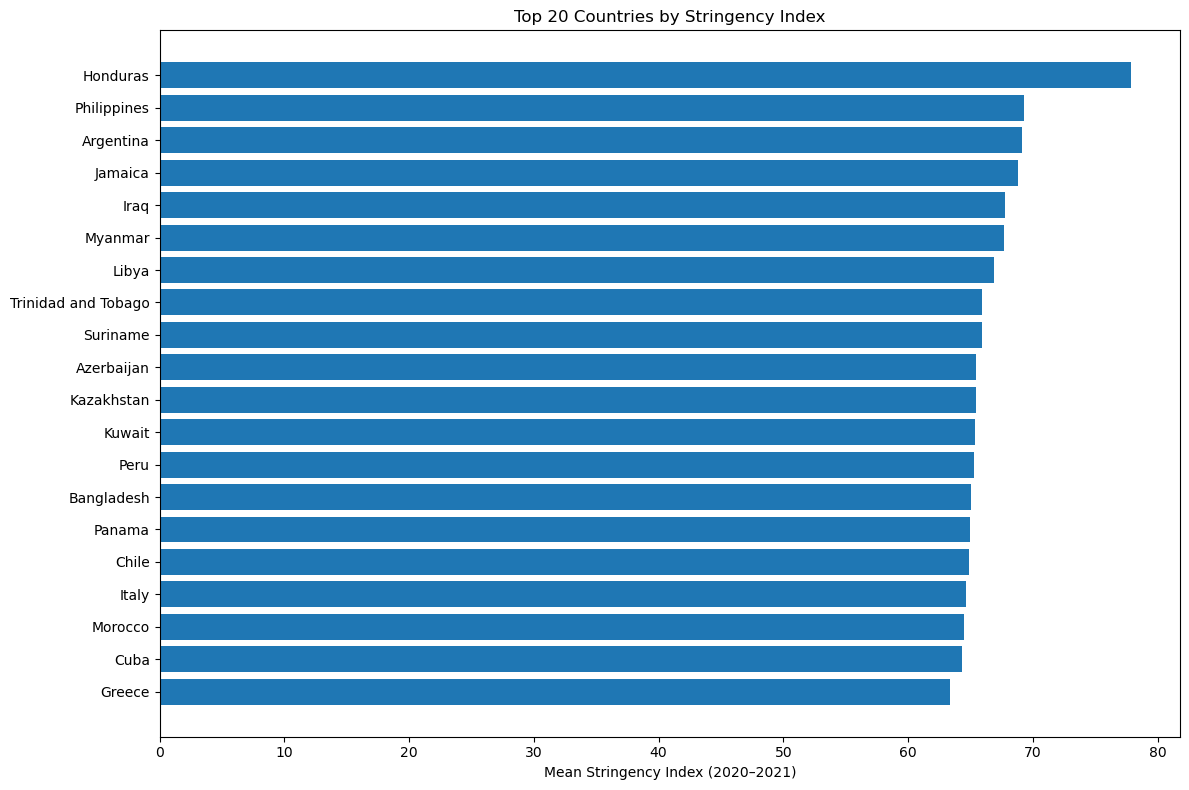

In [37]:
# Create column of mean during 2020-2021
data['Stringency_2020_2021'] = data[['StringencyIndex_2020', 'StringencyIndex_2021']].mean(axis=1)

# Rank
data['Rank'] = data['Stringency_2020_2021'].rank(ascending=False, method='min')

top20 = data.sort_values('Stringency_2020_2021', ascending=False).head(20)

# Get Australia's rank
australia_rank = int(data.loc['Australia', 'Rank']) 
print(f"Australia’s stringency rank: {australia_rank}")

# Create horizontal bar chart
plt.figure(figsize=(12,8))
# Reverse order so we get highest stringency on top
plt.barh(top20.index[::-1], top20['Stringency_2020_2021'][::-1])

plt.xlabel('Mean Stringency Index (2020–2021)')
plt.title('Top 20 Countries by Stringency Index')
plt.tight_layout()
plt.show()

Interestingly, the countries with the highest level of restrictions according to oxford was interesting as these countries were not notably mentioned for such high restrictions. Australia placed 63 in this ranking which was lower than exceptionations but may be due to reasons that will be discussed later on. 

**2. Rank the 20 countries with the lowest mean Stringency Index during 2020-2021?**

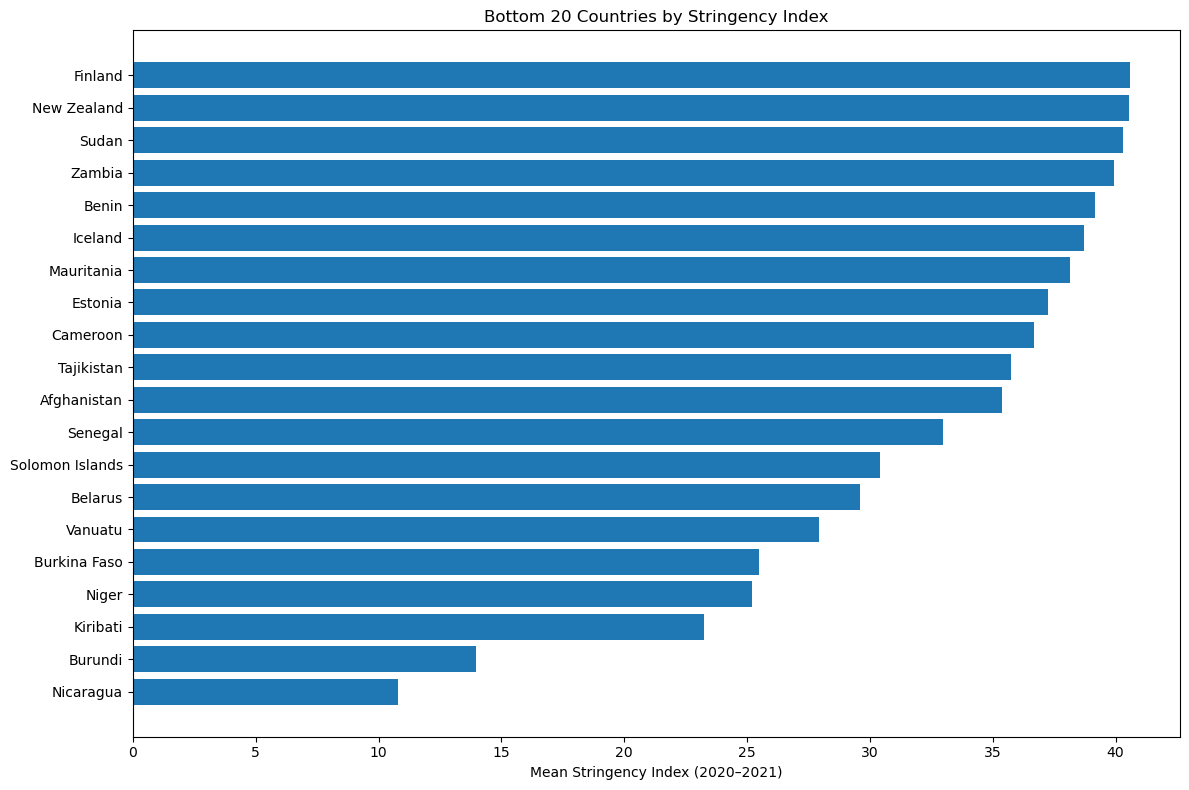

In [38]:
# Bottom 20 countries by stringency index
bottom20 = data.nsmallest(20, 'Stringency_2020_2021')

plt.figure(figsize=(12, 8))
plt.barh(bottom20.index, bottom20['Stringency_2020_2021'])
plt.xlabel('Mean Stringency Index (2020–2021)')
plt.title('Bottom 20 Countries by Stringency Index')
plt.tight_layout()
plt.show()

Some countries such as New Zealand were not excepted to be seen here as they too faced severe lockdowns but will be discussed later. Otherwise the graph looks as excepted.

**3. How did Australia’s economy perform during and after the pandemic compare to other countries with higher and lower Stringency Index?**

In [39]:
#Get df for australia then get df for top20 and bottom20 then average then gdp for years 2020-2023
australia_gdp = data.loc['Australia', ['GDPGrowth_2020', 'GDPGrowth_2021', 'GDPGrowth_2022', 'GDPGrowth_2023']]
bottom_gdp = bottom20[['GDPGrowth_2020', 'GDPGrowth_2021', 'GDPGrowth_2022', 'GDPGrowth_2023']].mean()
top_gdp = top20[['GDPGrowth_2020', 'GDPGrowth_2021', 'GDPGrowth_2022', 'GDPGrowth_2023']].mean()

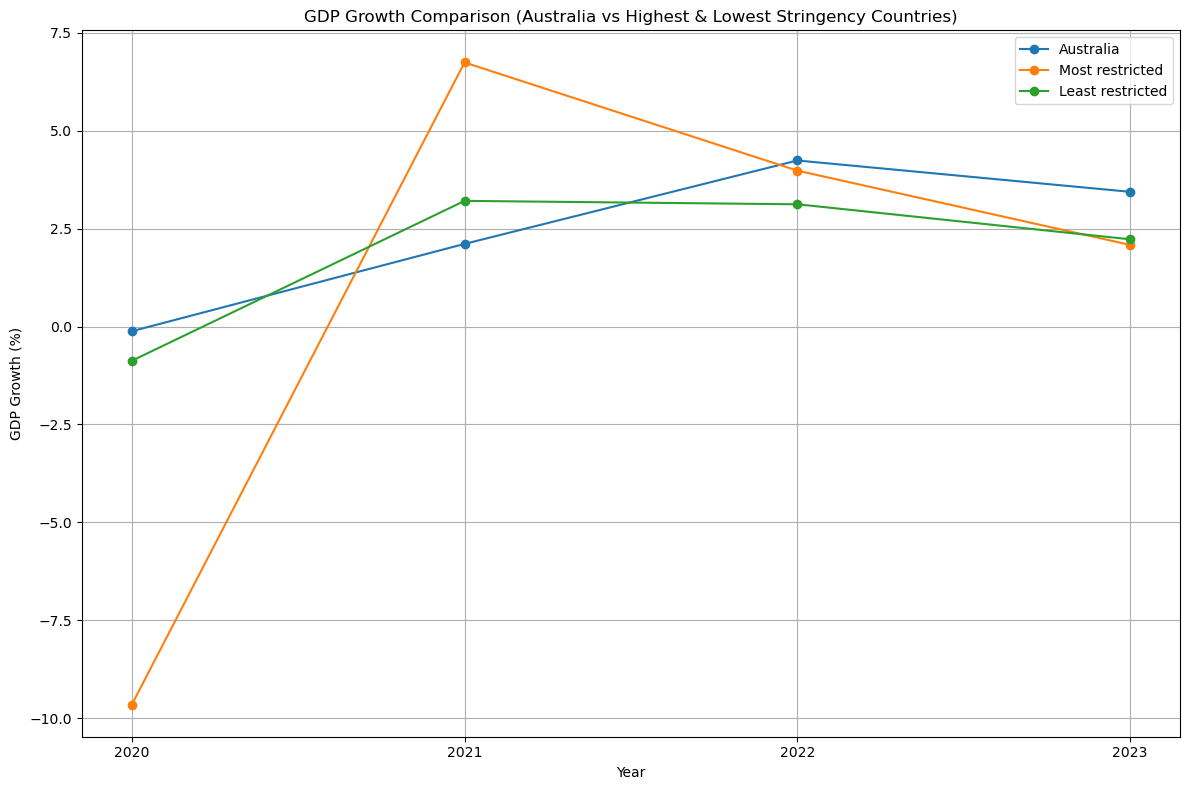

In [40]:
plt.figure(figsize=(12, 8))
#Plot for years from 2020-2023 
years = ['2020', '2021', '2022', '2023']
plt.plot(years, australia_gdp, label='Australia', marker='o')
plt.plot(years, top_gdp, label='Most restricted', marker='o')
plt.plot(years, bottom_gdp, label='Least restricted', marker='o')

plt.title('GDP Growth Comparison (Australia vs Highest & Lowest Stringency Countries)')
plt.ylabel('GDP Growth (%)')
plt.xlabel('Year')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Surprisingly Australia looked quite healthy as although it ranked 63 which was just a bit over the median of the ranking, its GDP growth was similar to those that were least stringent. Although it started off negative, it strongly recovered during 2021 but then decreased again from 2022 and 2023. For the most restricted countries, it started extremely low at nearly -10% where then they strongly bounced back but like the other groups experienced a downtrend.

**4. How was Australia's HDI affected during COVID, as compared to the world?**

In [41]:
# Get HDI for Australia and world

australia_hdi = data.loc['Australia', ['HDI_2019','HDI_2020', 'HDI_2021']]
global_hdi = data.drop(index='Australia')[['HDI_2019','HDI_2020', 'HDI_2021']].mean()

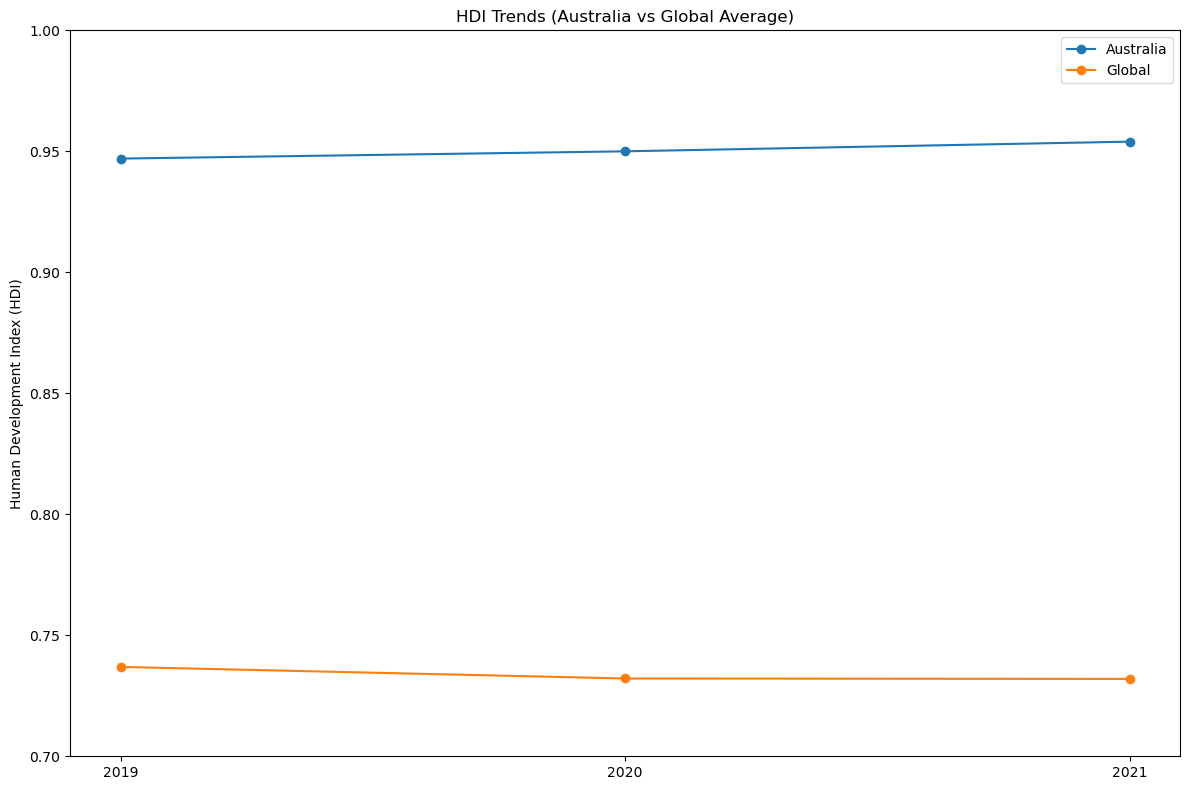

In [42]:
years = ['2019', '2020', '2021']
plt.figure(figsize=(12, 8))
plt.plot(years, australia_hdi, label='Australia', marker='o')
plt.plot(years, global_hdi, label='Global', marker='o')

plt.title('HDI Trends (Australia vs Global Average)')
plt.ylabel('Human Development Index (HDI)')
plt.ylim(0.7, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

Australia maintained a stable HDI during COVID and its consequential restrictions where it even experienced a slight increase whereas the global average unfortunely experienced a slight decline in its HDI.

**5. Did Australia experience a slower or faster recovery in terms of Human Development Index (HDI) compared to similar HDI countries?**

In [43]:
# Get Australia's 2020 hdi value
aus_hdi_2020 = data.loc['Australia', 'HDI_2020']

# Get rows with similar HDI within 0.05
similar_hdi = data['HDI_2020'].between(aus_hdi_2020 - 0.05, aus_hdi_2020 + 0.05)

similar = data[similar_hdi].copy()
similar

,StringencyIndex_2020,StringencyIndex_2021,StringencyIndex_2022,GDPGrowth_2020,GDPGrowth_2021,GDPGrowth_2022,GDPGrowth_2023,HDI_2019,HDI_2020,HDI_2021,HDI_2022,HDI_2023,DeathRate_2020,DeathRate_2021,DeathRate_2022,DeathRate_2023,Stringency_2020_2021,Rank
CountryName,,,,,,,,,,,,,,,,,,
Australia,51.669736,56.385487,27.979104,-0.119591,2.111168,4.242386,3.441992,0.947,0.950,0.954,0.952,0.958,3.586850,5.672481,59.347902,24.487088,54.027611,63.0
Austria,47.065219,61.624356,38.745479,-6.318255,4.795329,5.277894,-0.954962,0.928,0.925,0.930,0.927,0.930,79.052456,106.500851,55.121457,10.545611,54.344787,61.0
Belgium,51.530628,50.114904,15.462110,-4.792984,6.202554,4.233432,1.251701,0.945,0.939,0.948,0.945,0.951,167.905927,76.107816,43.218401,9.323497,50.822766,77.0
Canada,53.481395,58.355035,22.598828,-5.038233,5.286957,3.819866,1.248927,0.937,0.931,0.937,0.935,0.939,38.744485,39.532044,47.689908,15.013307,55.918215,53.0
Cyprus,53.173251,59.171479,22.921342,-3.220634,11.387763,7.365623,2.611901,0.907,0.905,0.907,0.908,0.913,8.754100,39.702150,46.418351,8.104234,56.172365,51.0
Denmark,46.365027,46.205589,13.531205,-1.780106,7.382066,1.540173,2.495184,0.953,0.954,0.958,0.959,0.962,19.875145,34.797557,76.486053,29.948115,46.285308,98.0
Estonia,36.383579,38.122658,21.536658,-2.883810,7.154447,0.060428,-3.023036,0.901,0.901,0.899,0.902,0.905,21.361061,116.008932,66.649862,17.879479,37.253118,124.0
Finland,38.731503,42.453205,16.356192,-2.491036,2.734713,1.450048,-1.163963,0.947,0.947,0.949,0.946,0.948,11.176330,21.981524,123.503763,48.532292,40.592354,117.0
France,54.293115,52.678247,19.813233,-7.440646,6.882338,2.570840,0.936488,0.914,0.909,0.915,0.916,0.920,93.983664,89.369823,55.097321,9.342854,53.485681,65.0


In [44]:
# Get recovery

similar['HDI_change'] = (similar['HDI_2023'] - similar['HDI_2021']) / 2
aus_recovery = similar.loc['Australia', 'HDI_change']
similar_recovery = similar.drop('Australia')['HDI_change'].mean()
similar_recovery

0.002239130434782606

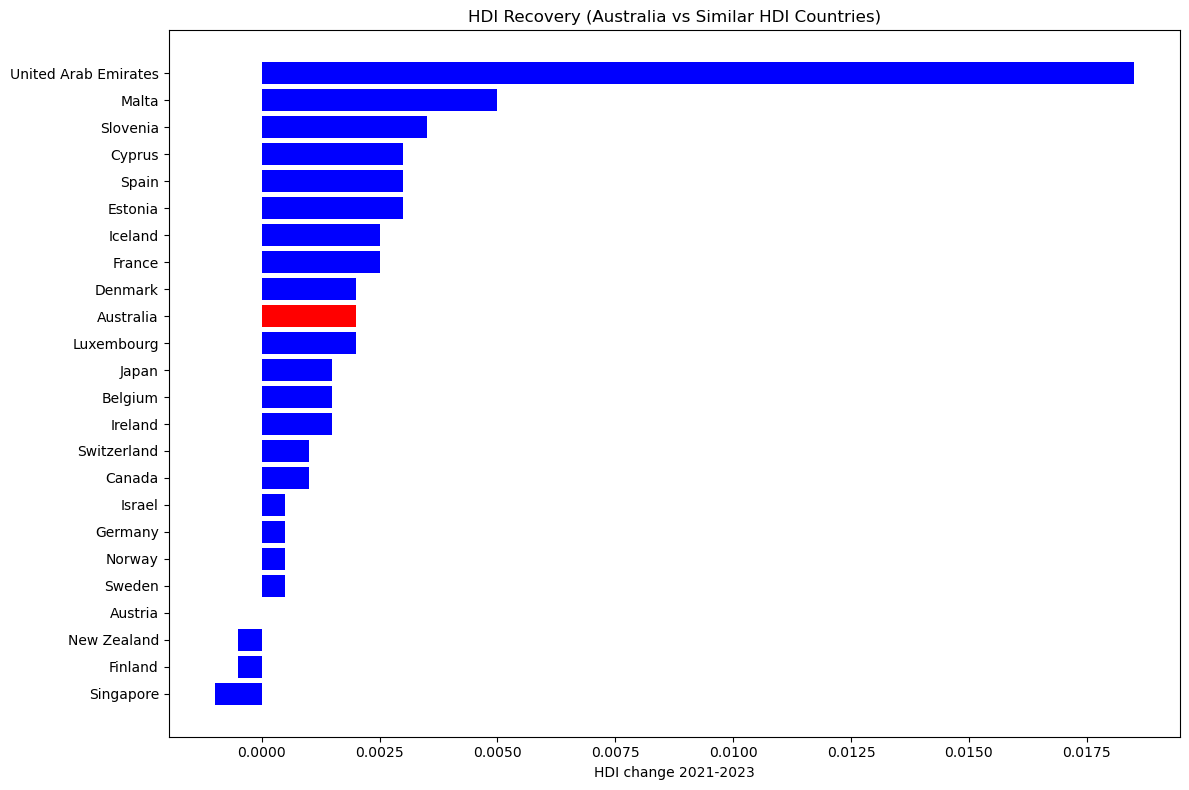

In [45]:
# Sort countries by recovery
similar_sorted = similar.sort_values('HDI_change')

# Make Australia a different colour to stand out
plt.figure(figsize=(12, 8))
plt.barh(similar_sorted.index, similar_sorted['HDI_change'], color=['red' if c=='Australia' else 'blue' for c in similar_sorted.index])

plt.xlabel('HDI change 2021-2023')
plt.title('HDI Recovery (Australia vs Similar HDI Countries)')
plt.tight_layout()
plt.show()

The graph tells us that although Australia did experience an slight increase in HDI following COVID, it was only in the middle compared to its peers with similar HDI in 2019 (pre-COVID).

**6. Are a country's pre COVID HDI proportional to its economic recovery?**

In [50]:
# Get GDP growth
data['Recovery_GDP_Growth'] = data[['GDPGrowth_2022', 'GDPGrowth_2023']].sum(axis=1)

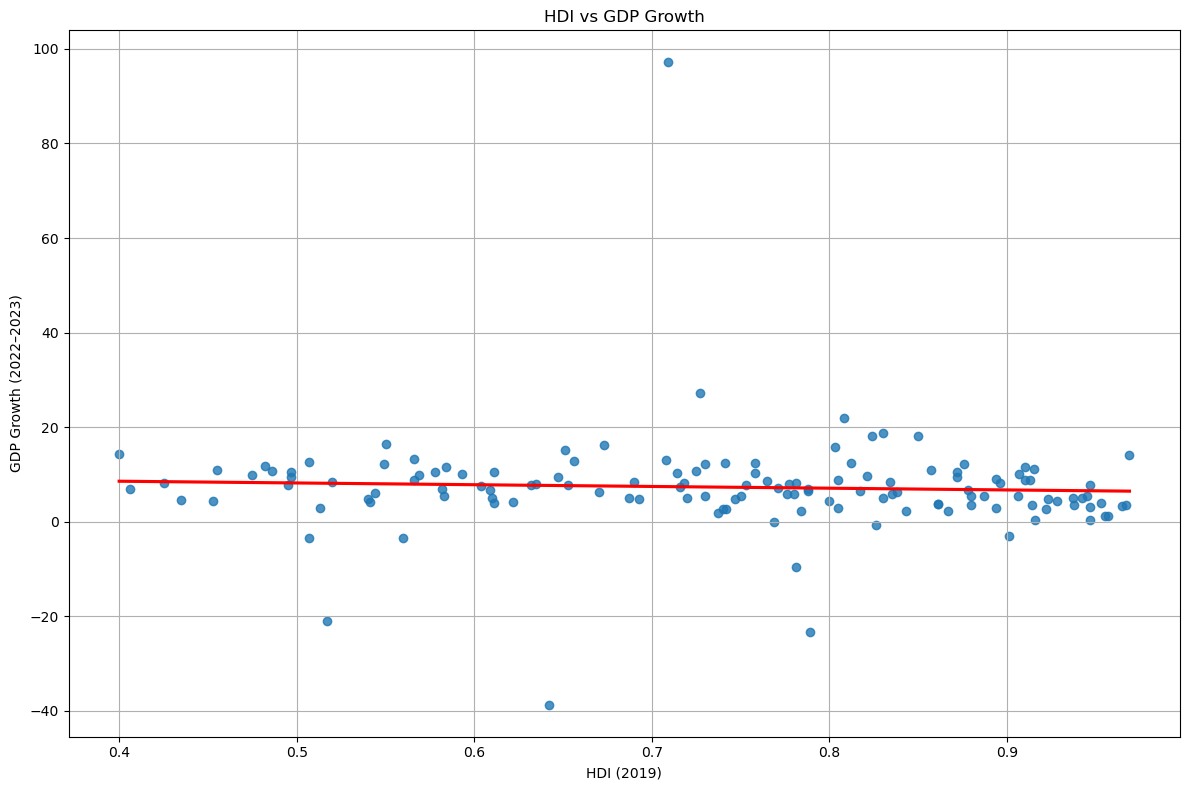

In [55]:
plt.figure(figsize=(12, 8))
sns.regplot(data=data, x='HDI_2019', y='Recovery_GDP_Growth',ci=None, line_kws={'color':'red'})
plt.xlabel('HDI (2019)')
plt.ylabel('GDP Growth (2022–2023)')
plt.title('HDI vs GDP Growth')
plt.grid(True)
plt.tight_layout()
plt.show()

The regression line shows that there is little to no correlation between GDP recovery and pre-COVID HDI for a country. Thus Australia being a high HDI country has no advantage in this aspect.

**7. To what extent did Australia's strict lockdown policies reduce COVID deaths per 100k against other countries with higher and lower Stringency Index?**

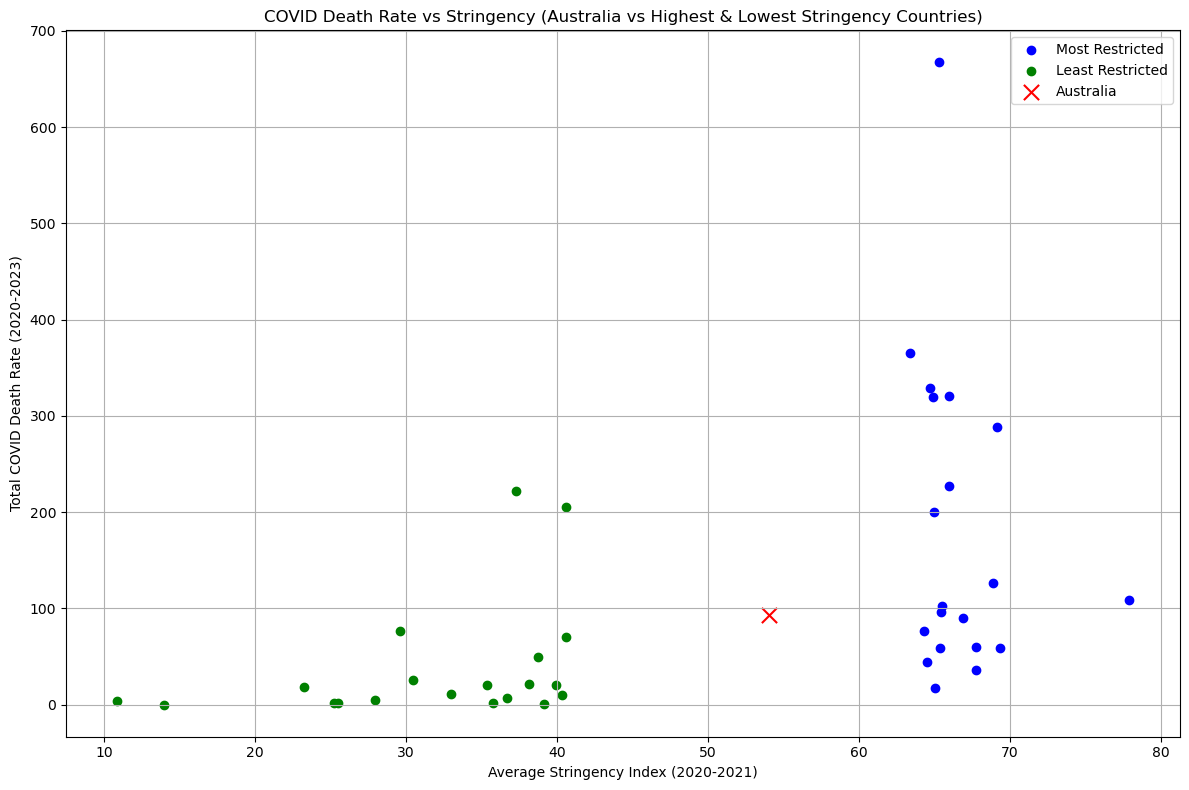

In [56]:
# Get total deaths
death_years = ['DeathRate_2020', 'DeathRate_2021', 'DeathRate_2022', 'DeathRate_2023']
top20['Total_DeathRate'] = top20[death_years].sum(axis=1)
bottom20['Total_DeathRate'] = bottom20[death_years].sum(axis=1)
data['Total_DeathRate'] = data[death_years].sum(axis=1)

# Plot scatter graph with different colours for each type
plt.figure(figsize=(12, 8))

# Plot top 20 (strict)
plt.scatter(top20['Stringency_2020_2021'], top20['Total_DeathRate'], label='Most Restricted', color='blue')

# Plot bottom 20 (lenient)
plt.scatter(bottom20['Stringency_2020_2021'], bottom20['Total_DeathRate'], label='Least Restricted', color='green')

# Get Australia
aus_x = data.loc['Australia', 'Stringency_2020_2021']
aus_y = data.loc['Australia', 'Total_DeathRate']
plt.scatter(aus_x, aus_y, color='red', s=120, marker='x', label='Australia')

plt.xlabel('Average Stringency Index (2020-2021)')
plt.ylabel('Total COVID Death Rate (2020-2023)')
plt.title('COVID Death Rate vs Stringency (Australia vs Highest & Lowest Stringency Countries)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



The scatterplot shows us that Australia's performance in balacing restrictions and mitigating COVID deaths were somewhat succesfully as they had less COVID deaths per 100k than a few least stringent countries whilst still staying under a majority of more stringent countries.

## 4. Discussion

Looking back at this report, although some results were unexcepted such as the placement of Australia in the ranking of stringency restriction, it was still nevertheless successful. We answered the required questions and produced graphs that will help visualise the data. 

Interestingly, even with tough lockdowns, Australia’s GDP didn’t fall much more than other countries with less restrictions. In fact, its economic recovery after 2020 looked similar to countries with fewer restrictions. This might be due to a number of factors such as governmental policies, social behaviour and geography.

Yet there were abnormalies that may have been fixed given more resources. One instance is that officially there is 195 recognised countries as of right now but after merging and cleaning data only 136 countries remained. This is quite a bit of information loss and could have perhaps been improved with further datasets. 

Furthermore, coming into the report, expectations were that Australia would have ranked higher in terms of the Stringency Index given the extreme measures taken in places like Melbourne and Sydney. But since we decided to use national data, this may have muddled such cities since places like Perth or Adelaide may have not experience such high levels and thus further investigation is needed.

Lastly, GDP growth for highly restricted countries experienced a massive rebounce after 2020, this view may be skewed as they had just experience a substancial decline and thus was recovering from a unfavourable state. 

## 5. Conclusion

Australia succeeded in terms of keeping death rates down while also avoiding the worst economic outcomes. In a sense, it managed to balance out the levels of restrictions that it had place so that it could still maintain a respectable GDP growth whilst not seeing a high rate of death due to COVID like some other countries. HDI remained stable throughout the ordeal and even increase slightly but not as much as some of its peers.

## 6. Future Analysis

Although this analysis covered the impacts that COVID has had upon Australias' and the wider global community's GDP, HDI and death rates, further analysis could be done on other aspects related to the topic as it was very broad. This could be investigating more direct relationships such as mental health or the educational impact during and post COVID. Another avenue is to look into governement policies and how they affected the key metrics that was used in the report. as dicusssed earlier there may be significant differents between cities of a nation and thus a deep analysis of difference of key metrics between regions or cities may be beneficial. Lastly, more work can be done in regards to our missing data such as replicating this report again but with all the countries of the world. Some measurements taken from the dataset have been reported by the said countries and thus inconsistencies may arise from different methodology or underreporting hence improvements could be done to the validity of the data by comparing and incorporting multiple datasets from different reputable sources.

## 7. References

De Walque, D., Friedman, J., Gatti, R., & Mattoo, A. (2020). Retrieved June 14, 2025.[WHO Declares COVID-19 a Pandemic](https://pmc.ncbi.nlm.nih.gov/articles/PMC7569573/)

Global Health Data Exchange. (2021). Retrieved June 14, 2025. [Global Health Data Exchange](https://ghdx.healthdata.org/)

Ian Macreadie (2022). Retrieved June 14, 2025.[Reflections from Melbourne, the world’s most locked-down
city, through the COVID-19 pandemic and beyond](https://www.publish.csiro.au/MA/pdf/MA22002)

Worldometer (2025). Retrieved June 15, 2025. [How many countries are there in the world?](https://www.worldometers.info/geography/how-many-countries-are-there-in-the-world/)

Oxford COVID-19 Government Response Tracker (Hale et al.). (2023).Retrieved June 14, 2025. [Oxford Covid-19 Government Response Tracker (OxCGRT)](https://github.com/OxCGRT/covid-policy-dataset)

World Bank. (n.d.). Retrieved June 15, 2025, [World Development Indicators](https://databank.worldbank.org/reports.aspx?source=2&series=NY.GDP.MKTP.KD.ZG&country=)

United Nations Development Programme. (n.d.). Retrieved June 15, 2025.[Human Development Data Center](https://hdr.undp.org/data-center/documentation-and-downloads)

World Health Organization. (n.d.). Retrieved June 15, 2025. [WHO COVID-19 dashboard data](https://data.who.int/dashboards/covid19/data)

World Bank. (n.d.). Retrieved June 15, 2025. [Total population (indicator: SP.POP.TOTL)](https://data.worldbank.org/indicator/SP.POP.TOTL)